# Parte 1
### Configurar rutas y cargar datos

In [1]:
import pandas as pd
import pyreadstat
import os

# definir rutas relativas para salir de notebooks
ruta_origen = os.path.join("..", "data", "original", "ESTUDIANTES_PUBLICA_2023.sav")
ruta_destino = os.path.join("..", "data", "procesado", "datos_estudiantes_limpios.csv")

# asegurar existencia de la carpeta de destino
os.makedirs(os.path.dirname(ruta_destino), exist_ok=True)

# carga del archivo original sav
df_est, meta_est = pyreadstat.read_sav(ruta_origen)

# mostrar vista previa en jupyter
df_est.head()

,AGNO,ID,COD_DEPE2,ESTRATO_ANALITICO,RURAL_RBD,Q001,Q004SQ001,Q004SQ002,Q005SQ001,Q005SQ002,...,IND_AUTP_HAB_DIG1,IND_AUTP_HAB_DIG2,IND_NIVEL_MOT_TIC1,IND_NIVEL_MOT_TIC2,IND_VAL_TD_EST,IND_AUTP_FORM_PENSAR,IND_PERC_PROT_EST,IND_FREC_APR_ACT,IND_AUTP_APR_CLASES,IND_PERC_IMP_TD
0,2023.0,1.0,1.0,4.0,0.0,1.0,3.0,4.0,4.0,4.0,...,4.111111,3.0,2.500000,3.666667,2.714286,4.0,3.4,2.6,3.75,3.500
1,2023.0,2.0,1.0,4.0,0.0,1.0,3.0,3.0,3.0,3.0,...,3.777778,1.0,3.000000,2.000000,3.000000,3.5,2.8,2.4,2.75,3.000
2,2023.0,3.0,1.0,4.0,0.0,2.0,2.0,3.0,3.0,4.0,...,5.000000,4.0,4.000000,4.000000,4.000000,3.5,2.8,3.0,2.75,4.000
3,2023.0,4.0,1.0,4.0,0.0,1.0,2.0,3.0,3.0,4.0,...,4.555556,1.0,3.500000,1.333333,3.142857,3.0,2.2,3.2,2.25,3.000
4,2023.0,5.0,1.0,4.0,0.0,0.0,3.0,4.0,4.0,4.0,...,3.555556,4.0,3.666667,4.000000,3.285714,4.0,3.4,2.8,4.00,2.875


# Parte 2
### Filtrado, limpieza e imputacion

In [2]:
# mapeo de variables clave en mayusculas
variables_modelo = {
    "COD_DEPE2": "dependencia",
    "ESTRATO_ANALITICO": "estrato_analitico",
    "IND_FREC_USO_INT": "uso_internet_escolar",
    "IND_FREC_ACTS_TD": "actividades_digitales_aula",
    "IND_AUTP_HAB_DIG1": "habilidades_digitales_basicas",
    "IND_AUTP_HAB_DIG2": "habilidades_digitales_avanzadas",
    "IND_NIVEL_MOT_TIC1": "motivacion_creacion_tic",
    "IND_PERC_PROT_EST": "protagonismo_estudiantil",
    "IND_AUTP_APR_CLASES": "aprendizaje_con_tecnologia"
}

# filtrar y renombrar columnas
df_filtrado = df_est[list(variables_modelo.keys())].copy().rename(columns=variables_modelo)

# lista de indicadores numericos
columnas_numericas = [
    "uso_internet_escolar", "actividades_digitales_aula", 
    "habilidades_digitales_basicas", "habilidades_digitales_avanzadas", 
    "motivacion_creacion_tic", "protagonismo_estudiantil", 
    "aprendizaje_con_tecnologia"
]

# imputar nulos con la mediana
for col in columnas_numericas:
    df_filtrado[col] = df_filtrado[col].fillna(df_filtrado[col].median())

# eliminar filas con nulos faltantes
df_limpio = df_filtrado.dropna()

# guardar dataframe limpio en la ruta correcta
df_limpio.to_csv(ruta_destino, index=False, sep=";", decimal=",")
print(f"registros procesados exitosamente: {df_limpio.shape[0]}")

registros procesados exitosamente: 10326


# Parte 3
### Grafico de barras y exportacion de figura

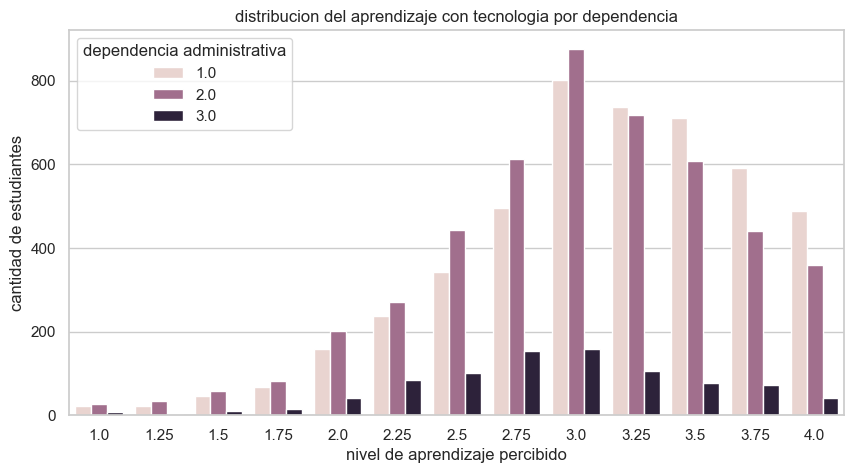

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# configurar estilo de graficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 5]

# definir ruta de salida de figuras
ruta_figuras = os.path.join("..", "resultados", "figuras")
os.makedirs(ruta_figuras, exist_ok=True)

# generar grafico de barras
sns.countplot(data=df_limpio, x="aprendizaje_con_tecnologia", hue="dependencia")
plt.title("distribucion del aprendizaje con tecnologia por dependencia")
plt.xlabel("nivel de aprendizaje percibido")
plt.ylabel("cantidad de estudiantes")
plt.legend(title="dependencia administrativa")

# guardar grafico en formato png
plt.savefig(os.path.join(ruta_figuras, "distribucion_aprendizaje.png"), dpi=300, bbox_inches="tight")
plt.show()

# Parte 4
### Mapa de calor y exportacion de resultados

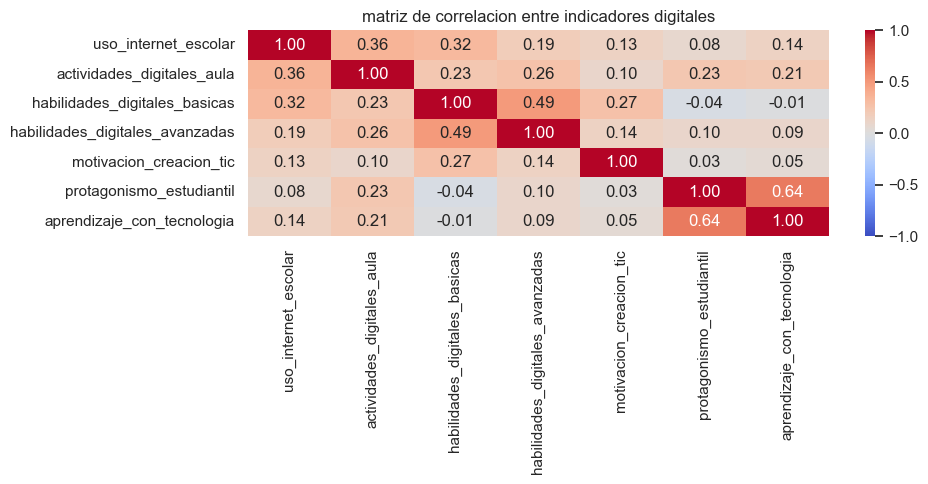

In [4]:
# definir ruta de salida de tablas
ruta_tablas = os.path.join("..", "resultados", "tablas")
os.makedirs(ruta_tablas, exist_ok=True)

# calcular matriz de correlacion
df_num = df_limpio[columnas_numericas]
matriz_corr = df_num.corr()

# guardar matriz como archivo csv
matriz_corr.to_csv(os.path.join(ruta_tablas, "matriz_correlacion.csv"), sep=";", decimal=",")

# generar mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("matriz de correlacion entre indicadores digitales")
plt.tight_layout()

# guardar mapa de calor en figuras
plt.savefig(os.path.join(ruta_figuras, "mapa_calor_correlacion.png"), dpi=300, bbox_inches="tight")
plt.show()